# Assignment3: Fashion-MNIST Classification with Multi-Layer Perceptron

## Summary
This assignment is about improving the performance of clothing type image classification using a Multi-Layer Perceptron (MLP).

## What you have to do
- **Please make sure to thoroughly read the notices provided below.**
- Copy this colab as `YOUR_STUDENT_ID.ipynb` to your google drive
  <br>(e.g. if your student id is 2024123456, save as 2024123456.ipynb)
- Modify the variables in the TODO section and train the model with different values (we call this hyperparameter tuning) to improve the model's performance.
- Download `YOUR_STUDENT_ID.ipynb` and submit the file to YS LearnUS <br>(again, if your student id is 2024123456, **your submission file name should be 2024123456.ipynb**)

## NOTICE
- **!!!!!IMPORTANT!!!!!**
- You **SHOULD NOT EDIT CODES OUTSIDE TODO BLOCK** for proper evaluation.
- This assignment will be automatically graded based on the test accuracy of the model you trained.
- **Do not remove output logs** from this file and submit it as it is.
- Attempting to deceive the automatic grading system will result in a **significant penalty**.
- Submissions that do not adhere to the guidelines will not be graded and will receive **zero points**.


# GRADING SCHEME
We will evaluate based on your model's test accuracy. For example, if your test accuracy is 88.7, your assignment score will be 90 points. <br>
The scoring criteria are as follows:
- 30  ( test accuracy >= 00.00 )
- 50  ( test accuracy > 80.00 )
- 80  ( test accuracy > 88.00 )
- 90  ( test accuracy > 88.50 )
- 100 ( test accuracy > 89.00 )

## Reference
- [Python documentation](https://docs.python.org/3/)
- [Keras documentation](https://keras.io/about/)
- [pandas documentation](https://pandas.pydata.org/docs/)
- Materials on [YS LearnUS](https://ys.learnus.org/)

## Library Imports and Data Preparation
- The following code covers library imports and data preparation steps that are essential for building the Multi-Layer Perceptron model.
- Load the Fashion-MNIST dataset from keras. Here, x contains the input image (28 * 28), and y contains the label (0 ~ 9).

In [ ]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense , Activation
from keras.utils import to_categorical, plot_model
from keras.optimizers import SGD
from keras.datasets import fashion_mnist

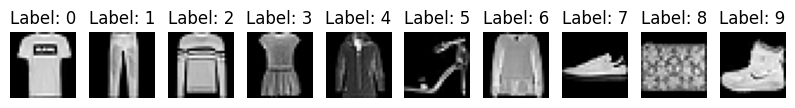

Train labels:  {0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}
Test labels:  {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


In [ ]:
# Load Fashion-MNIST dataset
(x_train, y_train),(x_test, y_test) = fashion_mnist.load_data()

# Examples and label counts of Fashion-MNIST dataset
indexes = [np.where(y_train == digit)[0][0] for digit in range(10)]
images = x_train[indexes]
labels = y_train[indexes]

plt.figure(figsize=(10, 4))
for i in range(len(indexes)):
    plt.subplot(1, 10, i + 1)
    image = images[i]
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()
plt.close('all')

unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))
unique, counts = np.unique(y_test, return_counts=True)
print("Test labels: ", dict(zip(unique, counts)))

In [ ]:
# Data preparation
num_labels = len(np.unique(y_train))

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

image_size = x_train.shape[1]
input_size = image_size * image_size

x_train = np.reshape(x_train, [-1, input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1, input_size])
x_test = x_test.astype('float32') / 255

## Hyperparameter Tuning
- Change `EPOCHS`, `LEARNING_RATE`, `BATCH_SIZE`, and `HIDDEN_UNITS` to appropriate values.
- Build, train and test the Multi-Layer Perceptron model with the selected parameters.
- **Do not clear or delete the output cell!** The output is necessary for evaluation and grading.

In [ ]:
######################################
############# TODO START #############
######################################
# If you modify the code outside of this TODO block, you may receive a score of 0 points in the worst case.
# Your task is to improve the model's test score by changing the variables EPOCHS, BATCH SIZE, LEARNING RATE, and HIDDEN UNITS.
# You are allowed to edit only network parameters below.

# network parameters
EPOCHS = 250
LEARNING_RATE = 0.002
BATCH_SIZE = 32
HIDDEN_UNITS = 512

######################################
############# TODO END ###############
######################################

In [ ]:
# Build a 3-layer MLP model
model = Sequential()
model.add(Dense(HIDDEN_UNITS, input_dim=input_size))
model.add(Activation('relu'))
model.add(Dense(HIDDEN_UNITS))
model.add(Activation('relu'))
model.add(Dense(num_labels))
model.add(Activation('softmax'))

opt = SGD(learning_rate=LEARNING_RATE)
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                     │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_81 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_82 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 10)                  │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_83 (Activation)           │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

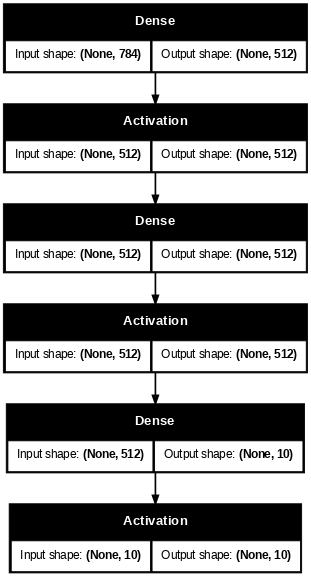

In [ ]:
# Summary and visualization of the model
model.summary()
plot_model(model, show_shapes=True, dpi=60)

In [ ]:
# Train the model
model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5728 - loss: 1.4615
Epoch 2/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7747 - loss: 0.7016
Epoch 3/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8090 - loss: 0.5844
Epoch 4/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8223 - loss: 0.5360
Epoch 5/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8288 - loss: 0.5061
Epoch 6/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8349 - loss: 0.4822
Epoch 7/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8406 - loss: 0.4640
Epoch 8/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8488 - loss: 0.4472
Epoch 9/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8479 - loss: 0.4461
Epoch 10/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8508 - loss: 0.4362
Epoch 11/250
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8527 - loss: 0.4302
Epoch 12/250
1875/1

In [ ]:
# Test the model

# NEVER MODIFY THIS CELL
# NEVER DELETE OUTPUT OF THIS CELL

loss, acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE)
print("\nTEST ACCURACY: %.2f%%" % (100.0 * acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8945 - loss: 0.3542

TEST ACCURACY: 89.44%
